# Juxtacrine OT Pipeline — Xenium-Format Toy Data

This notebook loads toy data written in the **exact 10x Genomics Xenium output format**
so the data loading code is identical to what you will use on a real Xenium dataset.

### Folder structure (mirrors a real Xenium output bundle)
```
toy_xenium_outs/
├── cells.csv.gz                 ← spatial coordinates + QC metrics
└── cell_feature_matrix/
    ├── barcodes.tsv.gz          ← one cell ID per line
    ├── features.tsv.gz          ← gene IDs and names
    └── matrix.mtx.gz            ← sparse count matrix (MEX format)
```

### To switch to real Xenium data later
Change **only** the `XENIUM_DIR` path in Cell 1.  
Everything else stays the same.


## 0. Installs & Imports

In [1]:
# Uncomment if running for the first time
# !pip install scanpy POT scikit-learn matplotlib --quiet

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scanpy as sc
from sklearn.decomposition import PCA
from scipy.spatial import cKDTree
import ot

sc.settings.verbosity = 1
np.random.seed(42)
print("Libraries loaded ✓")


Libraries loaded ✓


## 1. Set Data Path

`XENIUM_DIR` points to your Xenium output bundle folder.  
Change this one line when switching to real data — nothing else changes.


In [2]:
# ── Point this to your Xenium output bundle ───────────────────────
XENIUM_DIR = "/Users/anoushkasamuel/VSCode/research/cell-cell-interaction/toydatatrial/toy_xenium_outs"
# Derived paths (same structure in real Xenium data)
CELLS_CSV  = f"{XENIUM_DIR}/cells.csv.gz"
MTX_DIR    = f"{XENIUM_DIR}/cell_feature_matrix"

print(f"Xenium bundle: {XENIUM_DIR}")


Xenium bundle: /Users/anoushkasamuel/VSCode/research/cell-cell-interaction/toydatatrial/toy_xenium_outs


## 2. Load `cells.csv.gz` — Spatial Coordinates

This file contains one row per cell with spatial coordinates and QC metrics.  
Key columns:
- `cell_id` — unique cell identifier (e.g. `aaamobki-1`)  
- `x_centroid`, `y_centroid` — cell centre in microns  
- `transcript_counts` — total detected transcripts (use for QC filtering)  
- `cell_area`, `nucleus_area` — segmentation areas in µm²


In [3]:
cells_df = pd.read_csv(CELLS_CSV)
print(f"Cells loaded: {len(cells_df)} rows × {len(cells_df.columns)} columns")
print()
print(cells_df.columns.tolist())
cells_df.head(3)


Cells loaded: 240 rows × 12 columns

['cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'cell_type_ground_truth']


,cell_id,x_centroid,y_centroid,transcript_counts,control_probe_counts,control_codeword_counts,unassigned_codeword_counts,deprecated_codeword_counts,total_counts,cell_area,nucleus_area,cell_type_ground_truth
0,qahftrxc-1,46.217808,31.966882,264,0,0,0,0,264,88.36,56.50,Sender_DLL4
1,kafnafqo-2,86.550001,99.131844,251,0,0,0,0,251,182.89,67.97,Sender_DLL4
2,fpvausie-3,71.239576,16.189934,291,0,0,0,0,291,55.15,56.13,Sender_DLL4


## 3. Quick QC — Transcript Count Distribution

In real Xenium data, low-count cells are often empty droplets or debris.  
A typical filter is `transcript_counts >= 10`.


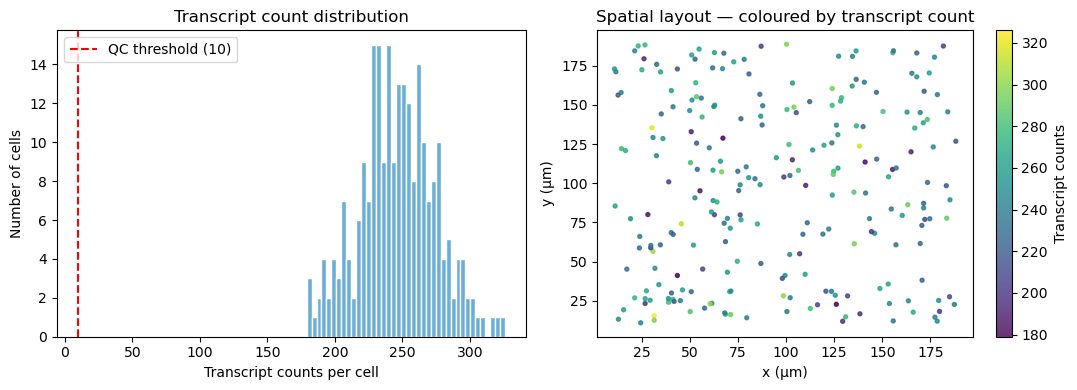

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].hist(cells_df["transcript_counts"], bins=40, color="#6baed6", edgecolor="white")
axes[0].set_xlabel("Transcript counts per cell")
axes[0].set_ylabel("Number of cells")
axes[0].set_title("Transcript count distribution")
axes[0].axvline(10, color="red", ls="--", label="QC threshold (10)")
axes[0].legend()

axes[1].scatter(cells_df["x_centroid"], cells_df["y_centroid"],
                c=cells_df["transcript_counts"], cmap="viridis",
                s=8, alpha=0.8)
axes[1].set_xlabel("x (µm)"); axes[1].set_ylabel("y (µm)")
axes[1].set_title("Spatial layout — coloured by transcript count")
plt.colorbar(axes[1].collections[0], ax=axes[1], label="Transcript counts")

plt.tight_layout()
plt.show()


## 4. Load `cell_feature_matrix/` — Gene Expression

`sc.read_10x_mtx()` reads the MEX-format sparse matrix and returns an `AnnData` object.  
We then attach the spatial coordinates from `cells.csv.gz` as `adata.obsm["spatial"]` —  
the standard key `squidpy` expects.


In [5]:
# Load the MEX count matrix
# var_names="gene_symbols" uses the gene name column from features.tsv.gz
adata = sc.read_10x_mtx(MTX_DIR, var_names="gene_symbols", cache=False)

# Attach spatial coordinates — must align cell order with cells_df
# cells_df rows are in the same order as barcodes.tsv.gz
adata.obs = adata.obs.join(
    cells_df.set_index("cell_id")[
        ["x_centroid", "y_centroid", "transcript_counts",
         "cell_area", "nucleus_area", "cell_type_ground_truth"]
    ]
)

# Store coordinates in the standard spatial key
adata.obsm["spatial"] = adata.obs[["x_centroid", "y_centroid"]].values

print(adata)
print()
print(f"Genes in panel:  {adata.n_vars}")
print(f"Cells:           {adata.n_obs}")


AnnData object with n_obs × n_vars = 240 × 50
    obs: 'x_centroid', 'y_centroid', 'transcript_counts', 'cell_area', 'nucleus_area', 'cell_type_ground_truth'
    var: 'gene_ids', 'feature_types'
    obsm: 'spatial'

Genes in panel:  50
Cells:           240


## 5. Preprocessing

Standard scanpy pipeline:
1. Filter low-count cells (QC)  
2. Normalise to 1,000 counts per cell (equivalent to CPM / 1000)  
3. Log1p transform  
4. PCA — this will be the latent space for OT  

In real data you might also run `sc.pp.highly_variable_genes()` here.  
We skip it since the toy panel is already small (50 genes).


In [6]:
# Filter very low-count cells
sc.pp.filter_cells(adata, min_counts=5)
print(f"After QC filter: {adata.n_obs} cells")

# Normalise + log transform
sc.pp.normalize_total(adata, target_sum=1_000)
sc.pp.log1p(adata)

# Store gene means before PCA (needed for inverse transform later)
import numpy as np
gene_means = np.asarray(adata.X.mean(axis=0)).flatten()

# PCA — 10 components, consistent with what OT will use
sc.pp.pca(adata, n_comps=10)

print("Preprocessing complete ✓")
print(f"PCA embedding shape: {adata.obsm['X_pca'].shape}")


After QC filter: 240 cells
Preprocessing complete ✓
PCA embedding shape: (240, 10)


## 6. Identify Sender and Receiver Cells

In real data you would identify:
- **Senders** = cells with high DLL4 expression  
- **Receivers** = cells with high NOTCH1 expression  

Here we use the ground truth labels we stored in `cell_type_ground_truth`  
*and* verify they agree with DLL4/NOTCH1 expression (they should — we built it that way).


In [7]:
# Ground truth labels (only available in toy data)
sender_mask   = adata.obs["cell_type_ground_truth"] == "Sender_DLL4"
receiver_mask = adata.obs["cell_type_ground_truth"] == "Receiver_NOTCH1"

print(f"Sender cells:   {sender_mask.sum()}")
print(f"Receiver cells: {receiver_mask.sum()}")

# In real data, use expression thresholds instead:
# dll4_expr   = adata[:, "DLL4"].X.toarray().flatten()
# sender_mask = dll4_expr > np.percentile(dll4_expr, 75)

# Verify: DLL4 should be high in senders
dll4_idx  = list(adata.var_names).index("DLL4")
notch_idx = list(adata.var_names).index("NOTCH1")

print(f"\nMean DLL4 expression:")
print(f"  Senders:   {adata[sender_mask].X[:, dll4_idx].mean():.3f}")
print(f"  Receivers: {adata[receiver_mask].X[:, dll4_idx].mean():.3f}")

print(f"\nMean NOTCH1 expression:")
print(f"  Senders:   {adata[sender_mask].X[:, notch_idx].mean():.3f}")
print(f"  Receivers: {adata[receiver_mask].X[:, notch_idx].mean():.3f}")


Sender cells:   40
Receiver cells: 200

Mean DLL4 expression:
  Senders:   4.377
  Receivers: 1.475

Mean NOTCH1 expression:
  Senders:   1.164
  Receivers: 4.188


## 7. Detect Juxtacrine Contact

We use a k-D tree on spatial coordinates to find which receiver cells  
are within `CONTACT_RADIUS` microns of a sender cell.

In real data with Xenium segmentation masks you could also use  
`squidpy.gr.spatial_neighbors(radius=CONTACT_RADIUS)` — identical logic.


Receiver cells in contact:     89
Receiver cells NOT in contact: 111


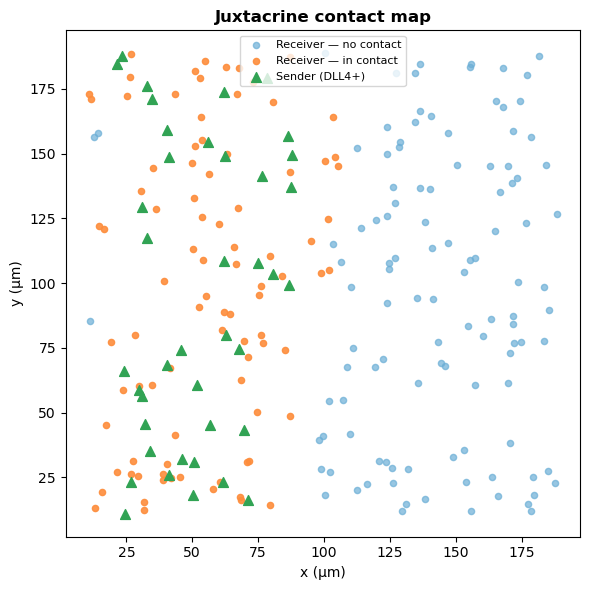

In [8]:
CONTACT_RADIUS = 20  # microns — direct membrane contact

# Extract coordinates
all_coords      = adata.obsm["spatial"]
sender_coords   = all_coords[sender_mask]
receiver_coords = all_coords[receiver_mask]

# k-D tree: find distance from each receiver to its nearest sender
sender_tree = cKDTree(sender_coords)
dist_to_sender, _ = sender_tree.query(receiver_coords, k=1)

# Boolean: is this receiver touching a sender?
in_contact = dist_to_sender < CONTACT_RADIUS
raw_signal = np.maximum(0, 1 - dist_to_sender / CONTACT_RADIUS)

print(f"Receiver cells in contact:     {in_contact.sum()}")
print(f"Receiver cells NOT in contact: {(~in_contact).sum()}")

# Visualise contact
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(receiver_coords[~in_contact, 0], receiver_coords[~in_contact, 1],
           c="#6baed6", s=20, alpha=0.7, label="Receiver — no contact")
ax.scatter(receiver_coords[in_contact, 0], receiver_coords[in_contact, 1],
           c="#fd8d3c", s=20, alpha=0.9, label="Receiver — in contact")
ax.scatter(sender_coords[:, 0], sender_coords[:, 1],
           c="#31a354", s=50, marker="^", label="Sender (DLL4+)")
ax.set_title("Juxtacrine contact map", fontweight="bold")
ax.set_xlabel("x (µm)"); ax.set_ylabel("y (µm)")
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()


## 8. Optimal Transport: X0 → X1

- **X0** = receiver cells NOT in contact (control / unperturbed)  
- **X1** = receiver cells IN contact (stimulated)  

We extract their PCA embeddings, compute a pairwise cost matrix,  
and solve the regularised OT problem with Sinkhorn.


In [9]:
# Get PCA embeddings for receiver cells only
receiver_pca = adata[receiver_mask].obsm["X_pca"]

X0_pca = receiver_pca[~in_contact]   # control
X1_pca = receiver_pca[in_contact]    # stimulated

print(f"X0 shape: {X0_pca.shape}   (control receivers × PCA dims)")
print(f"X1 shape: {X1_pca.shape}   (stimulated receivers × PCA dims)")

# Subsample for tractable OT computation
N_SUB = min(80, len(X0_pca), len(X1_pca))

idx0 = np.random.choice(len(X0_pca), N_SUB, replace=False)
idx1 = np.random.choice(len(X1_pca), N_SUB, replace=False)

X0_sub = X0_pca[idx0]
X1_sub = X1_pca[idx1]

# Uniform source/target weights
a = np.ones(N_SUB) / N_SUB
b = np.ones(N_SUB) / N_SUB

# Cost matrix: squared Euclidean in PCA space
M = ot.dist(X0_sub, X1_sub, metric="sqeuclidean")
M /= M.max()   # normalise for numerical stability

# Solve OT with Sinkhorn (entropic regularisation)
SINKHORN_REG = 0.05
transport_plan = ot.sinkhorn(a, b, M, reg=SINKHORN_REG, numItermax=1000)

print(f"\nTransport plan shape: {transport_plan.shape}")
print(f"Sum (should be ≈ 1):  {transport_plan.sum():.4f}")


X0 shape: (111, 10)   (control receivers × PCA dims)
X1 shape: (89, 10)   (stimulated receivers × PCA dims)

Transport plan shape: (80, 80)
Sum (should be ≈ 1):  1.0000


## 9. Estimate Gene Velocity

For each X0 cell, the **expected X1 landing position** is a weighted  
average of X1 cells, where weights come from the transport plan.  

Velocity = expected_X1 − X0  
Averaged across all cells → the overall signaling-induced gene shift.


In [10]:
# Normalise transport plan rows to sum to 1
plan_norm = transport_plan / (transport_plan.sum(axis=1, keepdims=True) + 1e-10)

# Expected landing position in PCA space
expected_X1_pca = plan_norm @ X1_sub   # (N_SUB × N_PCA)

# Project back to gene space using scanpy's stored PCA components
# adata.varm["PCs"] shape: (n_genes × n_comps) — note: transposed vs sklearn convention
# adata.uns["pca"]["params"]["zero_center"] tells us if mean was subtracted
pca_components = adata.varm["PCs"].T          # (n_comps × n_genes)
pca_mean       = gene_means                   # (n_genes,) — stored in preprocessing step

def pca_to_gene(pca_coords):
    """Inverse-transform PCA coords → gene space. pca_coords: (n_cells × n_comps)"""
    return pca_coords @ pca_components + pca_mean

X0_genes        = pca_to_gene(X0_sub)
expected_X1_genes = pca_to_gene(expected_X1_pca)

velocity_genes = expected_X1_genes - X0_genes      # (N_SUB × N_GENES)
mean_velocity  = velocity_genes.mean(axis=0)       # (N_GENES,)

print("Mean velocity vector shape:", mean_velocity.shape)
print("(One value per gene)")

# Top genes
gene_names = list(adata.var_names)
top_up   = np.argsort(mean_velocity)[-5:][::-1]
top_down = np.argsort(mean_velocity)[:5]

print(f"\nTop 5 UP-shifted genes:   {[gene_names[i] for i in top_up]}")
print(f"Top 5 DOWN-shifted genes: {[gene_names[i] for i in top_down]}")
print(f"\nExpected UP (ground truth):   HES1, HEY1, HEY2")
print(f"Expected DOWN (ground truth): MYC, CDK4")


Mean velocity vector shape: (50,)
(One value per gene)

Top 5 UP-shifted genes:   ['HEY1', 'HES1', 'DLL4', 'E2F1', 'HEY2']
Top 5 DOWN-shifted genes: ['HES5', 'HEYL', 'CDK4', 'GENE14', 'GENE06']

Expected UP (ground truth):   HES1, HEY1, HEY2
Expected DOWN (ground truth): MYC, CDK4


## 10. Evaluate Recovery

**Cosine similarity** between the OT-predicted velocity and the  
ground truth signal direction we planted when generating the toy data.


In [11]:
SIGNAL_DIRECTION = np.zeros(len(gene_names))
SIGNAL_DIRECTION[:5]  = [ 1.5,  1.2, -1.0,  0.8, -0.6]  # HES1,HEY1,HES5,HEY2,HEYL
SIGNAL_DIRECTION[5:10] = [-0.5,  0.4, -0.3,  0.6, -0.4]  # MYC,CCND1,CDK4,E2F1,PCNA

gt   = SIGNAL_DIRECTION / (np.linalg.norm(SIGNAL_DIRECTION) + 1e-10)
pred = mean_velocity    / (np.linalg.norm(mean_velocity) + 1e-10)

cosine_sim = np.dot(gt, pred)
print(f"Cosine similarity: {cosine_sim:.3f}")
print("(1.0 = perfect recovery, 0.0 = random)")


Cosine similarity: 0.777
(1.0 = perfect recovery, 0.0 = random)


## 11. Visualise Results


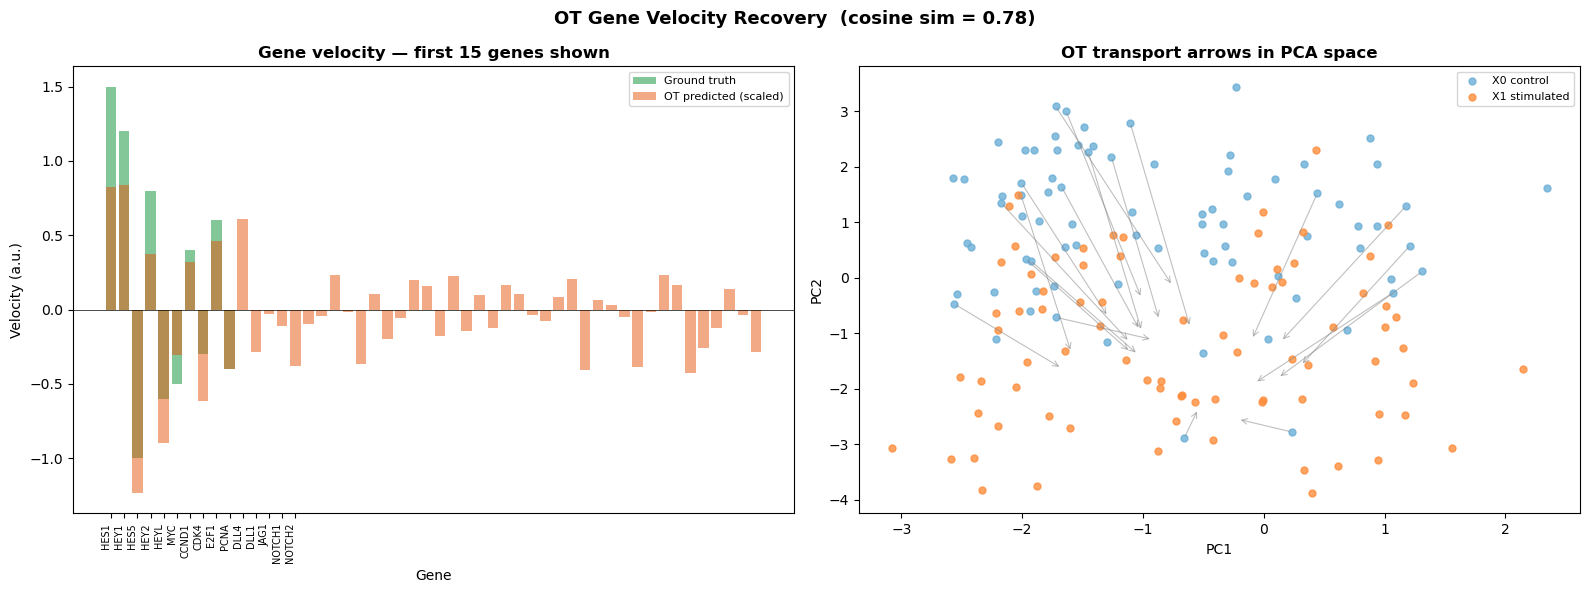

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(f"OT Gene Velocity Recovery  (cosine sim = {cosine_sim:.2f})",
             fontsize=13, fontweight="bold")

# Panel A: gene velocity bar chart
ax = axes[0]
x = np.arange(len(gene_names))
scale = np.linalg.norm(SIGNAL_DIRECTION) / (np.linalg.norm(mean_velocity) + 1e-10)
ax.bar(x, SIGNAL_DIRECTION, alpha=0.6, color="#31a354", label="Ground truth")
ax.bar(x, mean_velocity * scale, alpha=0.5, color="#e6550d", label="OT predicted (scaled)")
ax.axhline(0, color="black", lw=0.5)
ax.set_xticks(x[:15])
fig.set_size_inches(16, 6)

ax.set_xticklabels(gene_names[:15], rotation=90, ha="right", fontsize=7)
ax.set_xlabel("Gene"); ax.set_ylabel("Velocity (a.u.)")
ax.set_title("Gene velocity — first 15 genes shown", fontweight="bold")
ax.legend(fontsize=8)

# Panel B: OT transport arrows in PCA space
ax = axes[1]
ax.scatter(X0_sub[:, 0], X0_sub[:, 1], c="#6baed6", s=25, alpha=0.8, label="X0 control")
ax.scatter(X1_sub[:, 0], X1_sub[:, 1], c="#fd8d3c", s=25, alpha=0.8, label="X1 stimulated")
for i in np.random.choice(N_SUB, min(20, N_SUB), replace=False):
    ax.annotate("",
        xy=(expected_X1_pca[i, 0], expected_X1_pca[i, 1]),
        xytext=(X0_sub[i, 0], X0_sub[i, 1]),
        arrowprops=dict(arrowstyle="->", color="gray", lw=0.8, alpha=0.5))
ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
ax.set_title("OT transport arrows in PCA space", fontweight="bold")
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()


## 12. Swapping in Real Xenium Data

To run this notebook on a real 10x Genomics Xenium dataset, change  
**only Cell 1** to point to your downloaded Xenium output bundle:

```python
XENIUM_DIR = "/path/to/your/xenium_output_outs"
```

Download public Xenium datasets from:
- **10x Genomics**: https://www.10xgenomics.com/datasets  
  (search "Xenium breast cancer" or "Xenium human lung")
- **HuBMAP**: https://portal.hubmapconsortium.org  

The rest of the notebook — loading, preprocessing, contact detection,  
OT, and evaluation — runs identically on real data.

### One real-data adjustment
In Cell 6, replace the ground truth label lookup with an expression threshold:
```python
dll4_expr   = adata[:, "DLL4"].X.toarray().flatten()
sender_mask = dll4_expr > np.percentile(dll4_expr, 75)

notch1_expr   = adata[:, "NOTCH1"].X.toarray().flatten()
receiver_mask = notch1_expr > np.percentile(notch1_expr, 50)
```

And in Cell 10, remove the ground truth comparison —  
instead, validate against known Notch target genes (HES1, HEY1, HEY2)  
by checking if they appear in your top up-shifted genes.
